# Splitting strategy comparison

Compares two chunking strategies for the HP RAG pipeline:

- **Strategy A — token-based fixed-length** (current): `RecursiveCharacterTextSplitter.from_tiktoken_encoder`, 200 tokens, 20-token overlap.
- **Strategy B — character-based recursive**: `RecursiveCharacterTextSplitter`, ~800 characters (~200 tokens), 80-character overlap, separators `["\n\n", "\n", ". ", " ", ""]`. Splits on natural boundaries (paragraphs → sentences → words) before falling back to characters.

Chunk size is set to **200 tokens / ~800 characters** — safely below `all-MiniLM-L6-v2`'s 256-token context window. At 500 tokens both strategies were silently truncated to the same 256-token prefix, making the comparison meaningless. Reducing chunk size ensures the full chunk is encoded, so boundary quality actually affects the embedding.

Sections:
1. Chunk size distributions
2. Sentence boundary quality
3. Sample chunk inspection
4. Retrieval quality on HP test queries
5. Retrieval score curves

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import tiktoken
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer

/home/eloise/miniconda3/envs/hpquiz/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PDF_PATH    = "harrypotter.pdf"
EMBED_MODEL = "all-MiniLM-L6-v2"

docs = PyMuPDFLoader(PDF_PATH).load()
print(f"Loaded {len(docs)} pages")

# Strategy A: token-based fixed-length (current production setting)
splitter_A = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base",
    chunk_size=200,
    chunk_overlap=20,
)
chunks_A = splitter_A.split_documents(docs)

# Strategy B: character-based recursive
splitter_B = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=80,
    separators=["\n\n", "\n", ". ", " ", ""],
)
chunks_B = splitter_B.split_documents(docs)

# Strategy C: semantic chunking
# Embeds every sentence to find meaning-shift boundaries — takes several minutes on CPU
from langchain_experimental.text_splitter import SemanticChunker
from langchain_huggingface import HuggingFaceEmbeddings

_embeddings = HuggingFaceEmbeddings(model_name=EMBED_MODEL)
splitter_C = SemanticChunker(
    _embeddings,
    breakpoint_threshold_type="percentile",
    breakpoint_threshold_amount=95,
)
chunks_C = splitter_C.split_documents(docs)

STRATEGIES = [
    {"name": "A: token-based", "chunks": chunks_A, "color": "steelblue"},
    {"name": "B: char-based",  "chunks": chunks_B, "color": "coral"},
    {"name": "C: semantic",    "chunks": chunks_C, "color": "mediumseagreen"},
]

for s in STRATEGIES:
    print(f"{s['name']:20s}  {len(s['chunks']):,} chunks")

Loaded 3623 pages


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13892.89it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


A: token-based        10,272 chunks
B: char-based         10,213 chunks
C: semantic           9,234 chunks


## 1. Chunk size distributions

Token-based splitting produces a tight spike at 500 tokens. Character-based splitting produces a wider distribution because it respects natural text boundaries — some paragraphs are short, others long.

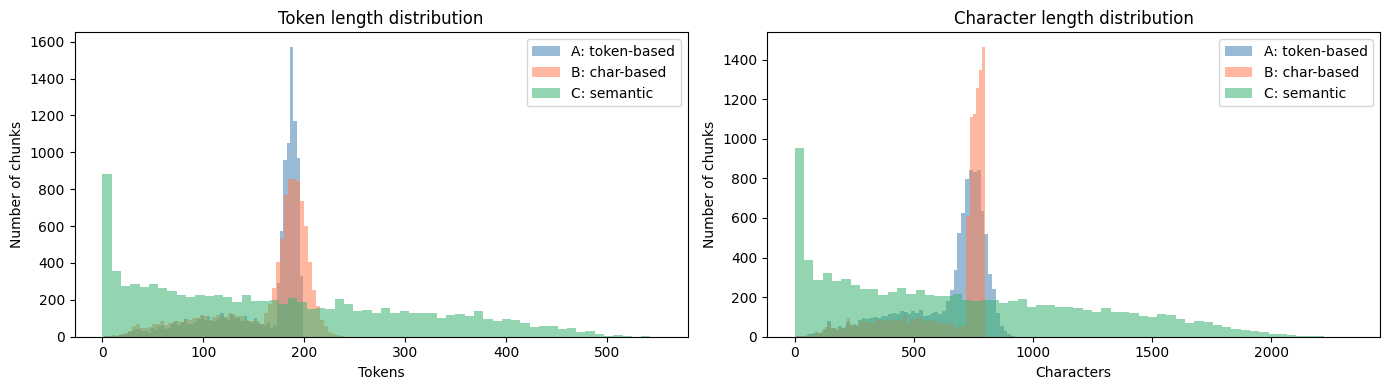

A: token-based        mean=  161  std=   44  min=   2  max= 199  n=10,272
B: char-based         mean=  163  std=   48  min=   2  max= 239  n=10,213
C: semantic           mean=  170  std=  132  min=   0  max= 552  n=9,234


In [3]:
enc = tiktoken.get_encoding("cl100k_base")

for s in STRATEGIES:
    s["tok"] = [len(enc.encode(c.page_content)) for c in s["chunks"]]
    s["chr"] = [len(c.page_content)             for c in s["chunks"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, key, xlabel, title in [
    (axes[0], "tok", "Tokens",     "Token length distribution"),
    (axes[1], "chr", "Characters", "Character length distribution"),
]:
    for s in STRATEGIES:
        ax.hist(s[key], bins=60, alpha=0.55, label=s["name"], color=s["color"])
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of chunks")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

for s in STRATEGIES:
    d = s["tok"]
    print(f"{s['name']:20s}  mean={np.mean(d):5.0f}  std={np.std(d):5.0f}"
          f"  min={min(d):4d}  max={max(d):4d}  n={len(d):,}")

## 2. Sentence boundary quality

A good chunk should start at a sentence or paragraph boundary and end at one too. Mid-sentence splits force the LLM to reason over incomplete context.

- **Ends at sentence boundary**: last non-whitespace character is `.`, `!`, `?`, `"`, or `'`
- **Starts mid-sentence**: first non-whitespace character is lowercase (continuation of a previous sentence)

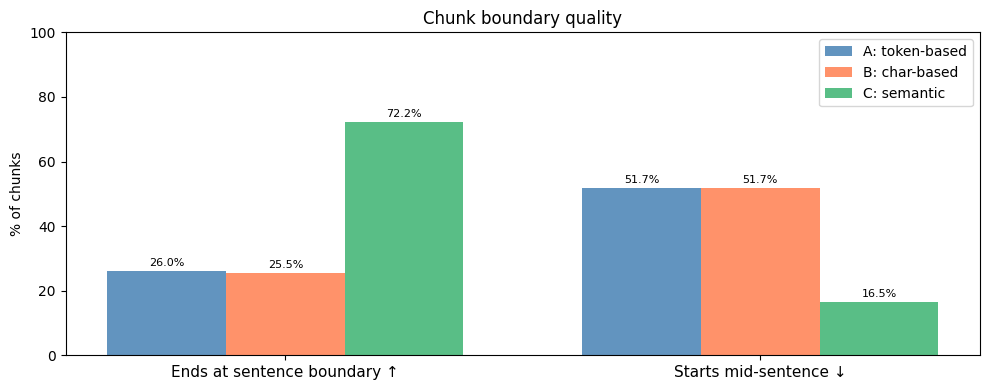

In [4]:
def boundary_stats(chunks):
    ends_sentence, starts_mid = 0, 0
    for c in chunks:
        text = c.page_content
        if text.rstrip() and text.rstrip()[-1] in ".!?\"'":
            ends_sentence += 1
        if text.lstrip() and text.lstrip()[0].islower():
            starts_mid += 1
    n = len(chunks)
    return ends_sentence / n * 100, starts_mid / n * 100

for s in STRATEGIES:
    s["end_pct"], s["mid_pct"] = boundary_stats(s["chunks"])

labels = ["Ends at sentence boundary ↑", "Starts mid-sentence ↓"]
x = np.arange(len(labels))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 4))
for i, s in enumerate(STRATEGIES):
    bars = ax.bar(x + (i - 1) * w, [s["end_pct"], s["mid_pct"]], w,
                  label=s["name"], color=s["color"], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("% of chunks")
ax.set_title("Chunk boundary quality")
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Sample chunk inspection

Side-by-side view of the same 3 random positions in the corpus. Pay attention to whether each chunk opens and closes on a complete thought.

In [5]:
random.seed(42)
PREVIEW = 350

# Sample by page number so all strategies show text from the same part of the corpus
sample_pages = random.sample(range(50, 3500), 3)

def chunk_at_page(chunks, page):
    """Return the first chunk whose page metadata is closest to the target page."""
    best, best_dist = chunks[0], float("inf")
    for c in chunks:
        d = abs(c.metadata.get("page", 0) - page)
        if d < best_dist:
            best, best_dist = c, d
    return best

for i, page in enumerate(sample_pages):
    print(f"{'═'*72}")
    print(f"  SAMPLE {i+1}  —  near PDF page {page}")
    print(f"{'─'*72}")
    for s in STRATEGIES:
        c = chunk_at_page(s["chunks"], page)
        tok = len(enc.encode(c.page_content))
        print(f"  [{s['name']}  {tok} tok]")
        print(f"  {c.page_content[:PREVIEW].strip()!r}")
        print()

════════════════════════════════════════════════════════════════════════
  SAMPLE 1  —  near PDF page 2669
────────────────────────────────────────────────────────────────────────
  [A: token-based  183 tok]
  'again.\nRon, whose hands and forearms still bore scratches and cuts from\nHermione’s bird attack, was taking a defensive and resentful tone.\n“She can’t complain,” he told Harry. “She snogged Krum. So she’s found\nout someone wants to snog me too. Well, it’s a free country. I haven’t done\nanything wrong.”\nHarry did not answer, but pretended to be absor'

  [B: char-based  199 tok]
  'again.\nRon, whose hands and forearms still bore scratches and cuts from\nHermione’s bird attack, was taking a defensive and resentful tone.\n“She can’t complain,” he told Harry. “She snogged Krum. So she’s found\nout someone wants to snog me too. Well, it’s a free country. I haven’t done\nanything wrong.”\nHarry did not answer, but pretended to be absor'

  [C: semantic  184 tok]
  'again. Ron, w

## 4. Retrieval quality

For a set of HP questions, embed the query and retrieve the top-3 most similar chunks from each strategy. Better splitting should return chunks that contain the answer in a readable, complete context — not a fragment that starts or ends mid-sentence.

In [6]:
model = SentenceTransformer(EMBED_MODEL)

for s in STRATEGIES:
    print(f"Embedding {s['name']}...")
    texts = [c.page_content for c in s["chunks"]]
    s["texts"] = texts
    s["embs"]  = model.encode(texts, batch_size=256, show_progress_bar=True,
                               normalize_embeddings=True)
print("Done.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11807.51it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding A: token-based...


Batches: 100%|██████████| 41/41 [00:12<00:00,  3.27it/s]


Embedding B: char-based...


Batches: 100%|██████████| 40/40 [00:13<00:00,  2.95it/s]


Embedding C: semantic...


Batches: 100%|██████████| 37/37 [00:09<00:00,  3.96it/s]

Done.


In [7]:
TEST_QUERIES = [
    "What is the name of Harry's owl?",
    "Who is the Defence Against the Dark Arts teacher in year one?",
    "What are the three Deathly Hallows?",
    "Where is the entrance to the Chamber of Secrets?",
    "How does Harry destroy the Horcrux in the diary?",
]

CONTEXT_CHARS = 400

def top_k(query, embs, texts, k=3):
    q = model.encode([query], normalize_embeddings=True)
    scores = (embs @ q.T).squeeze()
    idx = np.argsort(scores)[::-1][:k]
    return [(float(scores[i]), texts[i]) for i in idx]

for query in TEST_QUERIES:
    print(f"\n{'═'*72}")
    print(f"  QUERY: {query}")
    for s in STRATEGIES:
        score, chunk = top_k(query, s["embs"], s["texts"])[0]
        print(f"\n  [{s['name']}]  score={score:.3f}")
        print(f"  {chunk[:CONTEXT_CHARS].strip()!r}")


════════════════════════════════════════════════════════════════════════
  QUERY: What is the name of Harry's owl?

  [A: token-based]  score=0.700
  'The snowy owl clicked her beak and fluttered down onto Harry’s arm.\n“Very smart owl you’ve got there,” chuckled Tom. “Arrived about five\nminutes after you did. If there’s anything you need, Mr. Potter, don’t hesitate\nto ask.”\nHe gave another bow and left.\nHarry sat on his bed for a long time, absentmindedly stroking Hedwig. The\nsky outside the window was changing rapidly from deep, velvety blue to'

  [B: char-based]  score=0.700
  'The snowy owl clicked her beak and fluttered down onto Harry’s arm.\n“Very smart owl you’ve got there,” chuckled Tom. “Arrived about five\nminutes after you did. If there’s anything you need, Mr. Potter, don’t hesitate\nto ask.”\nHe gave another bow and left.\nHarry sat on his bed for a long time, absentmindedly stroking Hedwig. The\nsky outside the window was changing rapidly from deep, velvety blue t

## 5. Retrieval score distribution

For each query, plot the top-20 cosine similarity scores from both strategies. A tighter gap between rank-1 and rank-2 scores suggests ambiguity; a sharp drop-off means the top chunk is clearly the best match.

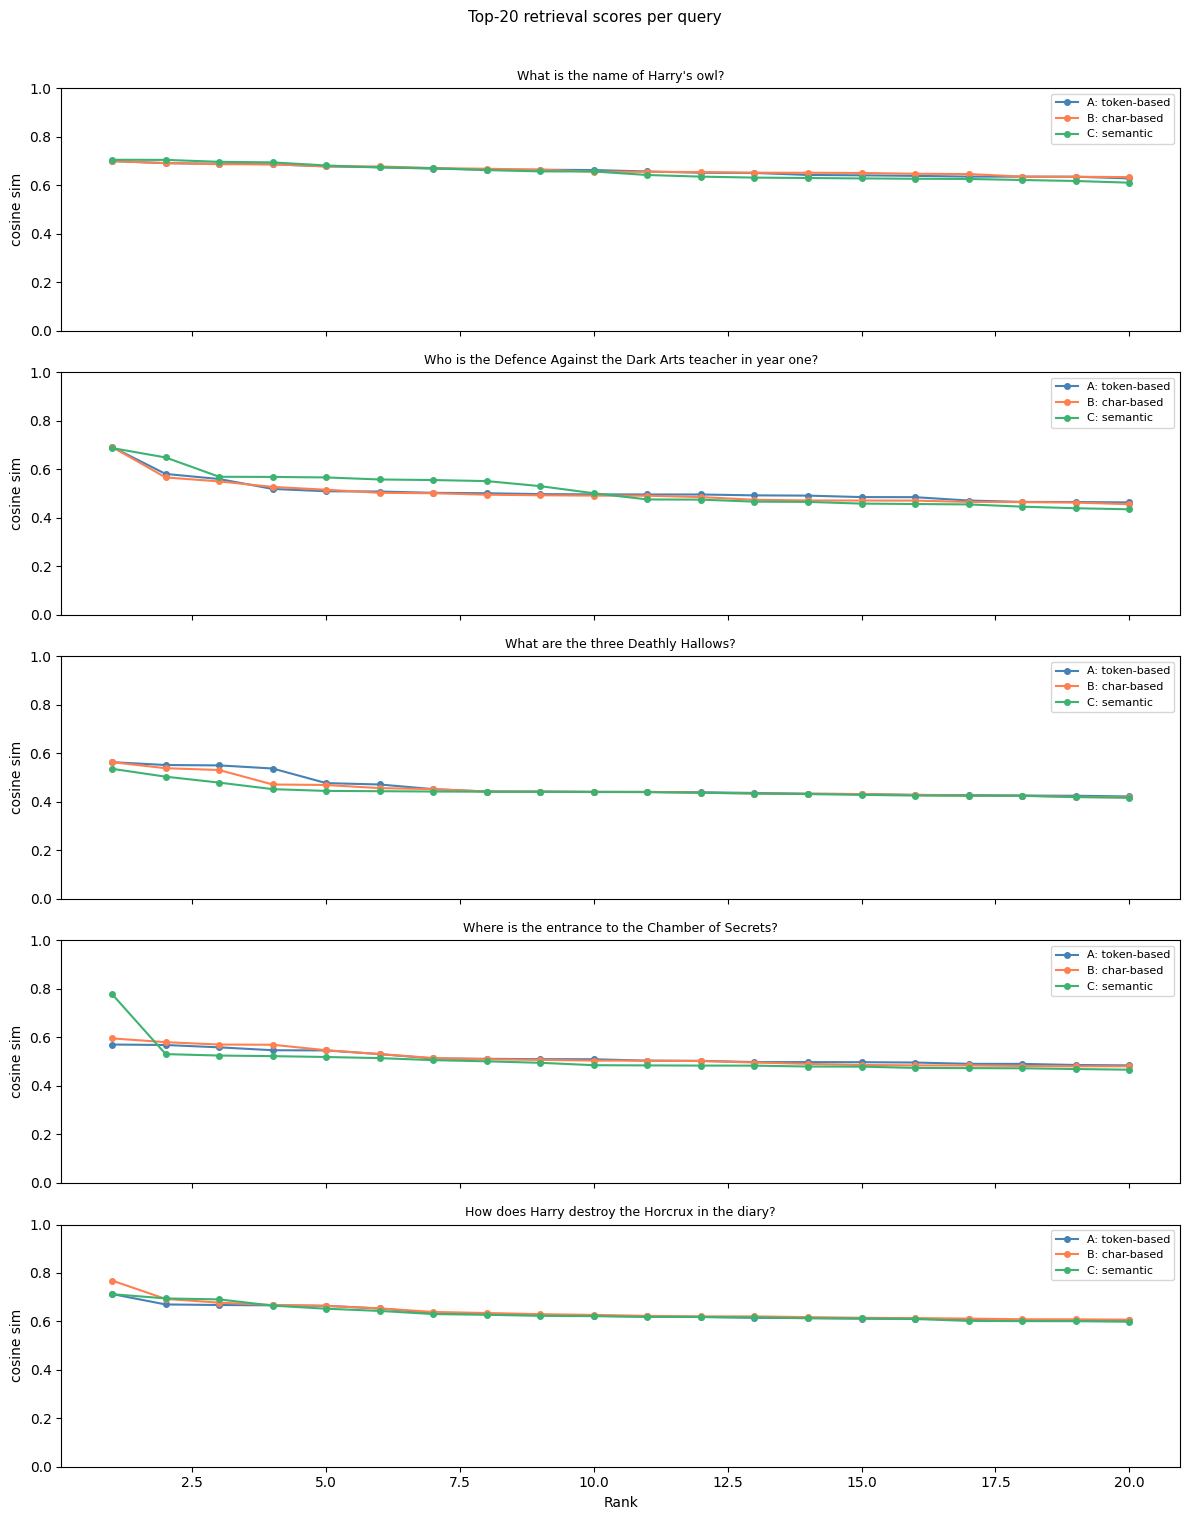

In [8]:
K_PLOT = 20

fig, axes = plt.subplots(len(TEST_QUERIES), 1, figsize=(12, 3 * len(TEST_QUERIES)), sharex=True)

for ax, query in zip(axes, TEST_QUERIES):
    for s in STRATEGIES:
        q = model.encode([query], normalize_embeddings=True)
        scores = np.sort((s["embs"] @ q.T).squeeze())[::-1][:K_PLOT]
        ax.plot(range(1, K_PLOT + 1), scores, marker="o", markersize=4,
                label=s["name"], color=s["color"], linewidth=1.5)
    ax.set_title(query, fontsize=9)
    ax.set_ylabel("cosine sim")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Rank")
plt.suptitle("Top-20 retrieval scores per query", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()